# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# 0. INSTALLS + IMPORTS
import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


In [2]:
# 1. LOAD THE CLASSROOM PACK
# Local first (notebook inside the pack root); Colab upload only if needed.

def find_pack_root(search_root):
    for candidate in [search_root, *search_root.rglob("*")]:
        if candidate.is_dir() and (candidate / "database" / "flasheats.db").exists():
            return candidate
    return None

BASE = find_pack_root(Path.cwd())

if BASE is None:
    try:
        from google.colab import files
        print("Upload FlashEats_Classroom_Pack.zip")
        uploaded = files.upload()
        zip_name = next(name for name in uploaded if name.endswith(".zip"))
        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall("/content")
        BASE = find_pack_root(Path("/content"))
    except Exception as e:
        print("Could not locate the pack:", e)

print("BASE:", BASE)
print("Exists:", BASE is not None and BASE.exists())

BASE: /home/claude/FlashEats_Classroom_Pack_V2
Exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | `orders.promised_eta` (Order DB, SQLite) | The order platform records the promise shown at checkout. Dispatch also has an ETA, but it's a *live, revised* estimate, not the original promise |
| Actual delivery time | `orders.actual_delivery_at` (Order DB) | The order platform owns order completion. `driver_events.delivered` is a second, driver-side signal to cross-check against |
| Driver assignment | Dispatch API | Dispatch creates assignments and reassignments. `driver_events.assigned` is a copy seen from the driver app |
| Customer complaint | `support_tickets.csv` | The only source of the customer's own words. Contextual, not an operational event log |
| Restaurant status | `restaurant_status.csv` | Owned by the restaurant system, but updated manually, so it's the right source with low trust |
| Driver movement/events | `driver_events.json` | Driver app GPS and state events. GPS is approximate and pings are sparse |

**Discussion:** the Order DB is authoritative for the order lifecycle (created, promised, delivered). Dispatch is authoritative for assignment and the *current* ETA. Tickets and restaurant status are contextual: they explain customer experience and suspected causes, but they are not events that define lateness.


In [3]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Decisions made **before coding**:

- **Late means:** `actual_delivery_at > promised_eta` (any delay beyond the promise shown to the customer).
- **Denominator:** unique orders whose status is *delivered* (case-insensitive) **and** that have a parseable `actual_delivery_at` and `promised_eta`.
- **Cancelled orders:** **exclude.** They were never delivered, so they cannot be late. They are counted and reported separately.
- **Missing actual delivery timestamp:** **exclude from the rate but report the count**, and show how far they could move the rate (best case / worst case). Never drop silently.
- **Row grain:** one row should be one order. Checked below, and it is not quite true (3 duplicate rows).

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.


In [4]:
orders = pd.read_sql("SELECT * FROM orders;", con)

print("Raw rows:", len(orders))
print("Unique orders:", orders["order_id"].nunique())
print("Extra duplicate rows:", len(orders) - orders["order_id"].nunique())

# Duplicates: are the copies identical?
dups = orders[orders["order_id"].duplicated(keep=False)].sort_values("order_id")
print("Columns that differ between duplicate copies:",
      sorted({c for _, g in dups.groupby("order_id") for c in g.columns if g[c].nunique(dropna=False) > 1}))

order_analysis = orders.drop_duplicates("order_id", keep="first").copy()

for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    parsed = pd.to_datetime(order_analysis[c], format="mixed", errors="coerce")
    print(f"{c}: unparseable = {(order_analysis[c].notna() & parsed.isna()).sum()}")
    order_analysis[c] = parsed

print("\nStatus values:", order_analysis["final_status"].value_counts().to_dict())
order_analysis["status_norm"] = order_analysis["final_status"].str.strip().str.lower()

is_delivered = order_analysis["status_norm"] == "delivered"
print("Cancelled:", (order_analysis["status_norm"] == "cancelled").sum())
print("Delivered with missing actual timestamp:",
      (is_delivered & order_analysis["actual_delivery_at"].isna()).sum())

valid = order_analysis[
    is_delivered &
    order_analysis["actual_delivery_at"].notna() &
    order_analysis["promised_eta"].notna()
].copy()

valid["delay_min"] = (valid["actual_delivery_at"] - valid["promised_eta"]).dt.total_seconds() / 60
late = valid[valid["delay_min"] > 0]

print("\nValid delivered:", len(valid))
print("Late:", len(late))
print("Late %:", round(100 * len(late) / len(valid), 1))
print("Median lateness among late orders:", round(late["delay_min"].median(), 1), "min")

print("\nWorst 10 delayed orders:")
display(late.sort_values("delay_min", ascending=False)[
    ["order_id", "promised_eta", "actual_delivery_at", "delay_min", "traffic_bucket", "weather_bucket"]
].head(10).assign(delay_min=lambda d: d["delay_min"].round(1)))

Raw rows: 1603
Unique orders: 1600
Extra duplicate rows: 3
Columns that differ between duplicate copies: ['traffic_bucket']
created_at: unparseable = 0
promised_eta: unparseable = 0
pickup_at: unparseable = 0
actual_delivery_at: unparseable = 0

Status values: {'delivered': 1527, 'cancelled': 68, 'Delivered': 5}
Cancelled: 68
Delivered with missing actual timestamp: 37

Valid delivered: 1495
Late: 843
Late %: 56.4
Median lateness among late orders: 8.0 min

Worst 10 delayed orders:


,order_id,promised_eta,actual_delivery_at,delay_min,traffic_bucket,weather_bucket
103,O00104,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.3,medium,clear
101,O00102,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.3,medium,clear
100,O00101,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.5,low,rain
102,O00103,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.3,high,clear
1080,O01081,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.3,high,clear
472,O00473,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.2,high,clear
1101,O01102,2026-08-12 19:31:12.651822,2026-08-12 20:16:09.835907,45.0,medium,clear
193,O00194,2026-08-11 19:01:48.000000,2026-08-11 19:40:08.111510,38.3,high,heavy_rain
1311,O01312,2026-08-14 20:17:36.000000,2026-08-14 20:54:36.321890,37.0,medium,clear
1402,O01403,2026-08-24 18:47:36.000000,2026-08-24 19:24:32.047659,36.9,medium,heavy_rain


In [5]:
# 5. Which data-quality issues actually change the metric?
n, k = len(valid), len(late)
missing = int((is_delivered & order_analysis["actual_delivery_at"].isna()).sum())
case_sensitive = order_analysis[(order_analysis["final_status"] == "delivered") &
                                order_analysis["actual_delivery_at"].notna()]

impact = pd.DataFrame([
    ["Chosen method", n, round(100 * k / n, 1)],
    ["Case-sensitive filter (== 'delivered')", len(case_sensitive),
     round(100 * ((case_sensitive["actual_delivery_at"] > case_sensitive["promised_eta"]).mean()), 1)],
    ["Cancelled kept in denominator", len(order_analysis) , round(100 * k / len(order_analysis), 1)],
    [f"Best case: all {missing} missing timestamps on time", n + missing, round(100 * k / (n + missing), 1)],
    [f"Worst case: all {missing} missing timestamps late", n + missing, round(100 * (k + missing) / (n + missing), 1)],
], columns=["variant", "denominator", "late_%"])
display(impact)

# Is the headline driven by a few big delays or many small ones?
bands = pd.cut(late["delay_min"], [0, 5, 10, 20, 1000], labels=["0-5 min", "5-10 min", "10-20 min", "20+ min"])
display(bands.value_counts().sort_index().rename("late orders").to_frame()
        .assign(share_of_late=lambda d: (100 * d["late orders"] / d["late orders"].sum()).round(1)))

,variant,denominator,late_%
0,Chosen method,1495,56.4
1,Case-sensitive filter (== 'delivered'),1490,56.4
2,Cancelled kept in denominator,1600,52.7
3,Best case: all 37 missing timestamps on time,1532,55.0
4,Worst case: all 37 missing timestamps late,1532,57.4


,late orders,share_of_late
delay_min,,
0-5 min,283,33.6
5-10 min,211,25.0
10-20 min,226,26.8
20+ min,123,14.6


### Challenge 1 findings

- **56.4% of 1,495 valid delivered orders (843) arrived after the promised ETA.** Median lateness among late orders is about 8 minutes.
- **Grain:** 1,603 rows for 1,600 orders. The 3 duplicate copies differ in `traffic_bucket`, so de-duplication doesn't change the late rate, but it does decide which traffic bucket those orders fall under in Challenge 2.
- **Status casing:** 5 orders are stored as `Delivered`. A case-sensitive filter silently drops them (1,490 instead of 1,495). The rate barely moves here, but it's the kind of bug that makes two teams' counts disagree.
- **Missing completion:** 37 delivered orders have no delivery time. They could move the rate anywhere between about 55.0% and 57.4%, so the headline is robust to them.
- **The worst "delays" are data defects.** The top 4 orders (O00101–O00104, about 70–87 minutes late) are exactly the rows whose promised ETA is 10 minutes *before* the order was created. Their true lateness is unknowable. The first genuine worst case is O01081 at about 50 minutes.
- **Shape of the problem:** most late orders are late by a few minutes. The problem is broad and shallow, not a small number of disasters. This already suggests the promise itself may be too tight.


## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [6]:
valid["traffic"] = valid["traffic_bucket"].str.strip().str.lower()    # 'HIGH' -> 'high' (representation only)
valid["late"] = valid["delay_min"] > 0
valid["promise_min"] = (valid["promised_eta"] - valid["created_at"]).dt.total_seconds() / 60
valid["transit_min"] = (valid["actual_delivery_at"] - valid["pickup_at"]).dt.total_seconds() / 60
valid["hour"] = valid["created_at"].dt.hour
valid["time_of_day"] = pd.cut(valid["hour"], [0, 11, 15, 18, 22, 24], right=False,
                              labels=["morning", "lunch", "afternoon", "dinner", "late_night"])

def summarise(col):
    return (valid.groupby(col, observed=True)
            .agg(orders=("order_id", "count"),
                 late_rate=("late", "mean"),
                 median_delay=("delay_min", "median"),
                 promised_min=("promise_min", "mean"),
                 transit_min=("transit_min", "mean"))
            .assign(late_rate=lambda d: (100 * d["late_rate"]).round(1))
            .round(1))

traffic_order = ["low", "medium", "high", "severe"]
print("Comparison 1 — traffic")
display(summarise("traffic").reindex(traffic_order))
print("Comparison 2 — weather")
display(summarise("weather_bucket").reindex(["clear", "rain", "heavy_rain"]))
print("Comparison 3 — time of day")
display(summarise("time_of_day"))

Comparison 1 — traffic


,orders,late_rate,median_delay,promised_min,transit_min
traffic,,,,,
low,360,49.4,-0.1,66.2,40.0
medium,588,51.4,0.3,68.6,43.6
high,424,66.5,4.0,72.9,49.5
severe,123,65.9,4.3,79.9,58.4


Comparison 2 — weather


,orders,late_rate,median_delay,promised_min,transit_min
weather_bucket,,,,,
clear,1192,53.3,0.8,69.2,43.9
rain,231,67.1,4.3,72.9,50.7
heavy_rain,72,73.6,6.6,76.7,57.7


Comparison 3 — time of day


,orders,late_rate,median_delay,promised_min,transit_min
time_of_day,,,,,
lunch,384,55.7,1.2,71.0,46.3
afternoon,262,60.3,3.1,70.4,45.7
dinner,700,54.9,1.2,69.8,45.2
late_night,149,58.4,2.0,69.3,45.7


Late rate (%) by traffic x weather


weather_bucket,clear,rain,heavy_rain
traffic,,,
low,47.5,56.6,66.7
medium,47.9,63.4,69.4
high,64.2,73.6,80.0
severe,60.0,83.3,100.0


Orders per cell (small cells are unreliable)


weather_bucket,clear,rain,heavy_rain
traffic,,,
low,295,53,12
medium,470,82,36
high,332,72,20
severe,95,24,4


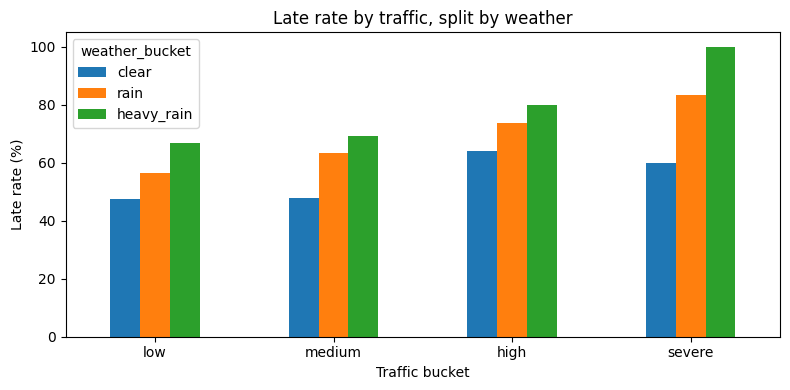

Distance estimate — share of orders at exactly 18.0 km: 50.1 %


count    1495.00
mean       14.62
std         4.75
min         0.50
25%        11.60
50%        18.00
75%        18.00
max        45.00
Name: distance_km_estimate, dtype: float64

Restaurant late rate spread:


count    60.0
mean     56.3
std       9.9
min      36.8
25%      50.0
50%      56.0
75%      62.6
max      84.6
Name: late_rate, dtype: float64

,orders,late_rate
restaurant_id,,
R001,13,84.6
R024,25,80.0
R031,23,73.9
R029,24,70.8
R054,20,70.0


In [7]:
# Is traffic confounded with weather? Hold weather fixed and look again.
strat = pd.crosstab(valid["traffic"], valid["weather_bucket"], values=valid["late"], aggfunc="mean") * 100
counts = pd.crosstab(valid["traffic"], valid["weather_bucket"])
strat = strat.reindex(traffic_order)[["clear", "rain", "heavy_rain"]].round(1)
print("Late rate (%) by traffic x weather")
display(strat)
print("Orders per cell (small cells are unreliable)")
display(counts.reindex(traffic_order)[["clear", "rain", "heavy_rain"]])

ax = strat.plot(kind="bar", rot=0, figsize=(8, 4))
ax.set_title("Late rate by traffic, split by weather")
ax.set_ylabel("Late rate (%)"); ax.set_xlabel("Traffic bucket")
plt.tight_layout(); plt.show()

# Distance: can we even use it?
print("Distance estimate — share of orders at exactly 18.0 km:",
      round(100 * (valid["distance_km_estimate"] == 18.0).mean(), 1), "%")
display(valid["distance_km_estimate"].describe().round(2))

# Restaurant: spread of late rate across restaurants
rest = valid.groupby("restaurant_id").agg(orders=("order_id", "count"), late_rate=("late", "mean"))
print("Restaurant late rate spread:")
display((rest["late_rate"] * 100).describe().round(1))
display(rest.sort_values("late_rate", ascending=False).head(5).assign(late_rate=lambda d: (100 * d["late_rate"]).round(1)))

### Challenge 2 findings

**Comparisons:**

| Dimension | What the data shows |
|---|---|
| Traffic | Late rate rises from ~49% (low) to ~66–67% (high/severe). Promised time *is* longer in heavy traffic, but actual transit grows faster than the padding |
| Weather | Clear ~53% → rain ~67% → heavy rain ~74% late |
| Traffic × weather | Traffic stays associated with lateness **within each weather level**, and heavy rain raises lateness **at every traffic level**. They look like two separate effects, not one confounding the other. Heavy-rain cells are small (4–36 orders) |
| Time of day | Flat (55–60%). Not a meaningful driver in this data |
| Distance | **Not usable.** 50% of orders have exactly 18.0 km, which looks like a placeholder or cap, so any distance result would be an artefact |
| Restaurant | Late rates range from ~37% to ~85%, but with 13–38 orders each, much of that spread could be noise |

**Hypothesis supported by evidence:** the ETA model under-adjusts for traffic and weather. It adds some padding in bad conditions, but not enough, so the promise is systematically too tight when conditions are poor.

**Alternative explanation I cannot rule out:** `traffic_bucket` may be recorded *after* the fact, or be partly derived from the delay itself. The 3 duplicate orders carry conflicting buckets, so it isn't clear when or how the field is assigned. If traffic is labelled from observed slowness, the association is circular. Restaurant preparation delay could also be hidden, because restaurant readiness isn't reliably recorded.

**Association vs causation:** Operations' claim that "traffic is the problem" is *consistent with* the data but not proven. Even in low traffic and clear weather, about 47% of orders are late, so traffic can't be the whole story.


# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [8]:
print("Ticket rows:", len(tickets))
print("Unique ticket IDs:", tickets["ticket_id"].nunique())
dup_ids = tickets[tickets["ticket_id"].duplicated(keep=False)]
print("Duplicate ticket IDs:", tickets["ticket_id"].duplicated().sum(),
      "| exact duplicate rows:", tickets.duplicated().sum())
display(dup_ids)
print("Tickets without an order_id:", tickets["order_id"].isna().sum())

tickets_u = tickets.drop_duplicates().copy()
print("\nComplaint categories (raw — note representation variants):")
display(tickets_u["category"].value_counts())

# Join customer view to system view
tickets_with_delay = tickets_u.merge(
    order_analysis[["order_id", "status_norm"]].merge(
        valid[["order_id", "delay_min", "late"]], on="order_id", how="left"),
    on="order_id", how="left")

tickets_with_delay["system_view"] = pd.cut(
    tickets_with_delay["delay_min"], [-1e9, 0, 10, 1e9], labels=["on time", "late 0-10", "late >10"]
).astype(str).replace("nan", "no delivery time / no order")

display(tickets_with_delay.groupby("category")["delay_min"].agg(["count", "median"]).round(1)
        .sort_values("count", ascending=False))
view = pd.crosstab(tickets_with_delay["category"], tickets_with_delay["system_view"])
display(view)
print("Tickets on orders the system says were ON TIME:",
      int((tickets_with_delay["delay_min"] <= 0).sum()))
print("Share of ALL late orders that produced a ticket:",
      round(100 * valid.loc[valid["late"], "order_id"].isin(tickets_u["order_id"]).mean(), 1), "%")

Ticket rows:

 202
Unique ticket IDs: 201
Duplicate ticket IDs: 1 | exact duplicate rows: 1


,ticket_id,order_id,created_at,category,customer_message
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.


Tickets without an order_id: 3

Complaint categories (raw — note representation variants):


category
late_delivery        37
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

,count,median
category,,
restaurant_delay,37,10.5
late_delivery,36,13.5
eta_changed,35,7.7
ready_but_waiting,33,12.2
status_mismatch,28,12.7
driver_not_moving,25,10.4
ETA issue,1,5.4
Late Delivery,1,15.5
late_delivery,1,25.6


system_view,late 0-10,late >10,on time
category,,,
ETA issue,1,0,0
Late Delivery,0,1,0
driver_not_moving,4,13,8
eta_changed,13,15,7
late_delivery,9,22,5
late_delivery,0,1,0
ready_but_waiting,12,18,3
restaurant_delay,9,19,9
status_mismatch,9,17,2


Tickets on orders the system says were ON TIME: 34
Share of ALL late orders that produced a ticket: 19.3 %


### Challenge 3 findings — system view vs customer view

| | System view (timestamps) | Customer view (tickets) |
|---|---|---|
| What counts as a problem | Any minute past `promised_eta` (56% of orders) | Mostly noticeable delays. Ticketed orders have a median delay of about 8–14 minutes depending on category, yet **34 tickets are on orders the system says were on time** |
| What goes wrong | "Late" as one number | Six different experiences: late, **ETA keeps changing**, **restaurant says ready but driver hasn't come**, driver not moving, status mismatch |
| Coverage | Every order | Only **19.3%** of late orders produce a ticket |
| Reliability | Structured, but blind to *why* | Subjective and messy: 1 duplicate ticket ID (an exact duplicate row), 3 tickets with no order, inconsistent category labels |

**Does the customer story match the operational story?** Partly. Tickets cluster on genuinely late orders, but complaints about *ETA changes* and *status mismatches* describe an **information problem**, not only a speed problem. Customers are upset that the app gives them inconsistent information, and a late-rate metric can't see that.

**What tickets reveal that timestamps can't:** which part of the experience failed (ETA reliability, restaurant readiness, driver movement), and how much delay customers actually tolerate. That makes tickets useful for choosing *which* lateness definition matters, but they're not an event log of what happened.


# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [9]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [10]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [11]:
RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

RETRYABLE = {429, 500, 502, 503, 504}

def fetch_all_dispatch_orders(page_size=100, max_retries=4, base_wait=1.0):
    """
    - fetch every page,
    - retry HTTP 500 / 429 with bounded exponential backoff,
    - preserve every successful raw response,
    - fail clearly on unrecoverable errors,
    - verify final record count.
    """
    records, attempts_log = [], []
    page, expected_total = 1, None

    while True:
        for attempt in range(1, max_retries + 1):
            response = requests.get(API_URL, params={"page": page, "page_size": page_size}, timeout=10)
            attempts_log.append({"page": page, "attempt": attempt, "status": response.status_code})

            if response.status_code in RETRYABLE:
                wait = float(response.headers.get("Retry-After", base_wait * 2 ** (attempt - 1)))
                print(f"page={page} attempt={attempt}/{max_retries} HTTP={response.status_code} -> retry in {wait:.0f}s")
                if attempt == max_retries:
                    raise RuntimeError(f"Page {page} still failing after {max_retries} attempts "
                                       f"(last HTTP {response.status_code}). Ingestion aborted.")
                time.sleep(wait)
                continue

            response.raise_for_status()        # non-retryable 4xx -> fail immediately
            break

        payload = response.json()

        # Preserve the raw response exactly as received, before any processing
        with open(RAW_DIR / f"dispatch_page_{page:03d}.json", "w") as f:
            json.dump(payload, f, indent=2)

        if expected_total is None:
            expected_total = payload["total_records"]
        elif payload["total_records"] != expected_total:
            raise RuntimeError("total_records changed during ingestion — source is not a stable snapshot")

        records.extend(payload["data"])
        print(f"page={page} rows={len(payload['data'])} running_total={len(records)} has_more={payload['has_more']}")

        if not payload["has_more"]:
            break
        page += 1

    return records, expected_total, pd.DataFrame(attempts_log)

dispatch_records, expected_total, attempts = fetch_all_dispatch_orders()

page=1 rows=100 running_total=100 has_more=True
page=2 rows=100 running_total=200 has_more=True
page=3 attempt=1/4 HTTP=500 -> retry in 1s


page=3 rows=100 running_total=300 has_more=True
page=4 rows=100 running_total=400 has_more=True
page=5 attempt=1/4 HTTP=429 -> retry in 1s


page=5 rows=100 running_total=500 has_more=True
page=6 rows=100 running_total=600 has_more=True
page=7 rows=100 running_total=700 has_more=True
page=8 rows=100 running_total=800 has_more=True
page=9 rows=100 running_total=900 has_more=True
page=10 rows=100 running_total=1000 has_more=True
page=11 rows=100 running_total=1100 has_more=True
page=12 rows=100 running_total=1200 has_more=True
page=13 rows=100 running_total=1300 has_more=True
page=14 rows=100 running_total=1400 has_more=True
page=15 rows=100 running_total=1500 has_more=True
page=16 rows=100 running_total=1600 has_more=False


In [12]:
# Prove completeness — several independent checks, not just "no error"
dispatch_df = pd.DataFrame(dispatch_records)
raw_files = sorted(RAW_DIR.glob("dispatch_page_*.json"))
raw_rows = sum(len(json.load(open(p))["data"]) for p in raw_files)

completeness = pd.DataFrame([
    ["Records retrieved == API total_records", f"{len(dispatch_df)} vs {expected_total}", len(dispatch_df) == expected_total],
    ["No duplicate order_id across pages", dispatch_df["order_id"].duplicated().sum(), dispatch_df["order_id"].is_unique],
    ["Raw pages on disk re-count to the same total", f"{len(raw_files)} files / {raw_rows} rows", raw_rows == expected_total],
    ["Every Order DB order found in Dispatch", order_analysis["order_id"].isin(dispatch_df["order_id"]).mean(),
     order_analysis["order_id"].isin(dispatch_df["order_id"]).all()],
    ["Every Dispatch order found in Order DB", dispatch_df["order_id"].isin(order_analysis["order_id"]).mean(),
     dispatch_df["order_id"].isin(order_analysis["order_id"]).all()],
], columns=["check", "evidence", "passed"])
display(completeness)

print("Failures encountered and recovered:")
display(attempts[attempts["status"] != 200])

print("Reassigned orders:", dispatch_df["reassigned_at"].notna().sum())
display(dispatch_df.head())

,check,evidence,passed
0,Records retrieved == API total_records,1600 vs 1600,True
1,No duplicate order_id across pages,0,True
2,Raw pages on disk re-count to the same total,16 files / 1600 rows,True
3,Every Order DB order found in Dispatch,1.0,True
4,Every Dispatch order found in Order DB,1.0,True


Failures encountered and recovered:


,page,attempt,status
2,3,1,500
5,5,1,429


Reassigned orders: 95


,assigned_at,current_delivery_eta,dispatch_status,driver_id,estimated_pickup_at,eta_model_version,order_id,original_driver_id,reassigned_at
0,2026-08-13T13:01:09.659644,2026-08-13T14:19:15.546424,completed,D103,2026-08-13T13:14:00,eta-v3.2,O00001,D103,NaN
1,2026-08-01T18:37:09.708219,2026-08-01T20:01:16.627988,completed,D083,2026-08-01T18:54:00,eta-v3.2,O00002,D083,NaN
2,2026-08-01T19:35:00.002443,2026-08-01T20:22:59.204700,completed,D039,2026-08-01T19:53:00,eta-v3.2,O00003,D039,NaN
3,2026-08-09T18:17:16.087835,2026-08-09T19:51:58.608301,cancelled,D038,2026-08-09T18:34:00,eta-v3.2,O00004,D038,NaN
4,2026-08-06T20:36:55.346822,2026-08-06T22:13:17.537116,completed,D047,2026-08-06T20:53:00,eta-v3.1,O00005,D047,NaN


In [13]:
# What does Dispatch add? Compare the ORIGINAL promise with Dispatch's CURRENT ETA.
d = valid.merge(dispatch_df, on="order_id", how="left")
d["current_eta"] = pd.to_datetime(d["current_delivery_eta"], format="mixed", errors="coerce")
d["eta_drift_min"] = (d["current_eta"] - d["promised_eta"]).dt.total_seconds() / 60
d["late_vs_current_eta"] = d["actual_delivery_at"] > d["current_eta"]
d["reassigned"] = d["reassigned_at"].notna()

print("ETA drift (current ETA - promised ETA), minutes:")
display(d["eta_drift_min"].describe().round(1))
print("Late vs ORIGINAL promise:", round(100 * d["late"].mean(), 1), "%")
print("Late vs CURRENT Dispatch ETA:", round(100 * d["late_vs_current_eta"].mean(), 1), "%")
display(d.groupby("reassigned")["late"].agg(["count", "mean"]).round(3).rename(columns={"mean": "late_rate"}))
display(d.groupby("eta_model_version")["late"].agg(["count", "mean"]).round(3).rename(columns={"mean": "late_rate"}))

ETA drift (current ETA - promised ETA), minutes:


count    1495.0
mean        9.0
std         7.7
min         0.0
25%         4.0
50%         8.3
75%        12.7
max        91.8
Name: eta_drift_min, dtype: float64

Late vs ORIGINAL promise: 56.4 %
Late vs CURRENT Dispatch ETA: 25.9 %


,count,late_rate
reassigned,,
False,1404,0.563
True,91,0.571


,count,late_rate
eta_model_version,,
eta-v3.1,742,0.551
eta-v3.2,753,0.576


### Challenge 4 findings

- **Retrieval is proven complete, not just successful.** All 16 pages were fetched. The HTTP 500 on page 3 and the 429 on page 5 were retried with a bounded backoff, and retrieval would have stopped with a clear error if they had kept failing. Completeness is shown by five separate checks: the record count matches `total_records`, there are no duplicate IDs across pages, the raw files on disk re-count to the same total, and the Order DB and Dispatch match in both directions.
- **Raw responses are preserved** in `student_output/raw_dispatch/` before any processing, so the analysis can be re-run or audited without calling the API again.
- **New insight: the ETA moves.** Dispatch's *current* ETA is always later than the original promise, by about 9 minutes on average. Against the original promise, 56% of orders are late. Against the ETA Dispatch ends up showing, only about 26% are. That explains the "ETA keeps changing" tickets. Which ETA counts as "the promise" is a business definition that needs an owner.
- Reassigned orders (95) and ETA model versions show little difference in late rate, so neither explains the problem.


# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.



In [14]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())


arrival_like = [t for t in driver_events_df["type"].unique() if "arriv" in t.lower()]
print("Event types containing 'arriv':", arrival_like or "none")

driver_events_df["ts"] = pd.to_datetime(driver_events_df["timestamp"], format="mixed", errors="coerce")
per_order = driver_events_df.pivot_table(index="order_id", columns="type", values="ts", aggfunc="min")
print("Orders in driver events:", len(per_order))

# Consistency with the Order DB
cmp = per_order.join(order_analysis.set_index("order_id")[["pickup_at", "actual_delivery_at"]], how="left")
cmp["pickup_diff_min"] = (cmp["picked_up"] - cmp["pickup_at"]).dt.total_seconds() / 60
cmp["delivery_diff_min"] = (cmp["delivered"] - cmp["actual_delivery_at"]).dt.total_seconds() / 60
print("Driver pickup vs Order DB pickup (minutes):"); display(cmp["pickup_diff_min"].describe().round(2))
print("Driver delivered vs Order DB delivered (minutes):"); display(cmp["delivery_diff_min"].describe().round(2))

# GPS cadence — could we infer arrival from pings?
gps = driver_events_df[driver_events_df["type"] == "gps_ping"].sort_values(["order_id", "ts"])
gap = gps.groupby("order_id")["ts"].diff().dt.total_seconds() / 60
print("Minutes between GPS pings:"); display(gap.describe().round(1))
print("Orders with no pickup event in driver app:", per_order["picked_up"].isna().sum())

# GPS jumps: implausible movement between consecutive pings
import numpy as np
gps = gps.assign(prev_lat=gps.groupby("order_id")["lat"].shift(), prev_lon=gps.groupby("order_id")["lon"].shift())
km = 111 * np.sqrt((gps["lat"] - gps["prev_lat"]) ** 2 + ((gps["lon"] - gps["prev_lon"]) * np.cos(np.radians(gps["lat"]))) ** 2)
print("GPS jumps > 20 km between consecutive pings:", int((km > 20).sum()))

# Reconciliation: can the driver app fill Order DB gaps? (reported, NOT written back)
missing_ids = order_analysis.loc[is_delivered & order_analysis["actual_delivery_at"].isna(), "order_id"]
recovered = cmp.loc[cmp.index.isin(missing_ids), ["delivered"]].join(
    order_analysis.set_index("order_id")["promised_eta"])
print(f"\nOrder DB delivered-without-timestamp: {len(missing_ids)} | present in driver app: {recovered['delivered'].notna().sum()}")
k2 = len(late) + int((recovered["delivered"] > recovered["promised_eta"]).sum())
n2 = len(valid) + int(recovered["delivered"].notna().sum())
print(f"Late rate if driver-app times were accepted: {k2}/{n2} = {100 * k2 / n2:.1f}% (vs 56.4%)")

bad_pickup = cmp[cmp["pickup_diff_min"].abs() > 0.01]
print("\nOrders where the two sources disagree on pickup time:")
display(bad_pickup[["pickup_at", "picked_up", "pickup_diff_min", "actual_delivery_at"]].round(1))

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

...

Minutes between GPS pings:


count    3839.0
mean       14.2
std         5.4
min         0.0
25%        11.0
50%        13.4
75%        16.9
max        41.0
Name: ts, dtype: float64

Orders with no pickup event in driver app: 68
GPS jumps > 20 km between consecutive pings: 155

Order DB delivered-without-timestamp: 37 | present in driver app: 37
Late rate if driver-app times were accepted: 867/1532 = 56.6% (vs 56.4%)

Orders where the two sources disagree on pickup time:


/tmp/ipykernel_1225/2561712692.py:55: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(bad_pickup[["pickup_at", "picked_up", "pickup_diff_min", "actual_delivery_at"]].round(1))


,pickup_at,picked_up,pickup_diff_min,actual_delivery_at
order_id,,,,
O00051,2026-08-01 16:24:51.495665,2026-08-01 15:25:54.609569,-58.9,2026-08-01 16:19:51.495665
O00052,2026-08-24 18:16:16.946011,2026-08-24 17:19:34.353083,-56.7,2026-08-24 18:11:16.946011
O00053,2026-08-13 18:25:53.797613,2026-08-13 17:42:23.641275,-43.5,2026-08-13 18:20:53.797613
O00054,2026-08-28 21:25:10.582862,2026-08-28 20:23:52.944934,-61.3,2026-08-28 21:20:10.582862
O00055,2026-08-16 14:08:05.645770,2026-08-16 13:20:04.394373,-48.0,2026-08-16 14:03:05.645770


### Challenge 5 findings

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | **Observed** | Dispatch API (authoritative), driver events (copy) | Reassignment means the first assignment isn't always the one that counts |
| Driver at restaurant | **Not observed**, inferred at best | GPS pings in driver events | No arrival event exists. Pings are a median of about 14 minutes apart (up to 41), with 155 jumps of more than 20 km between consecutive pings |
| Picked up | **Observed** | Order DB, driver events | The sources agree except for 5 orders, where the Order DB pickup is 43–61 minutes *later* than the driver app. These are exactly the 5 "delivered before pickup" rows, so the Order DB **pickup** is the wrong field, not delivery |
| Delivered | **Observed** | Order DB, driver events | All 37 delivery times missing from the Order DB exist in the driver app. Accepting them would move the rate to 56.6%. Reported as a reconciliation, **not written back** |

**Can we reliably tell when the driver arrived at the restaurant? No.** There is no stored arrival event, only GPS pings about 14 minutes apart (up to 41), with 155 implausible jumps of more than 20 km. That's far too sparse and noisy to pinpoint it. Without arrival, we can't split *order → pickup* time into "restaurant was slow" versus "driver was late", which is exactly the attribution the client needs. A geofence estimate would be **inferred**, not observed, and should be labelled that way.


# Final FDE synthesis — one slide

| | |
|---|---|
| **1. Problem size** | The data shows **56.4% of 1,495 valid delivered orders** arrived after the original promised ETA, with a median lateness of about 8 minutes. Using a "more than 10 minutes late" threshold it's roughly 23%. The problem is broad and shallow. |
| **2. Evidence** | Lateness **is associated with** high/severe traffic (~66% late) and rain/heavy rain (67–74%), each separately. Time of day isn't. Distance can't be assessed (half the values are a placeholder 18.0 km). Dispatch's ETA drifts about 9 minutes later than the original promise. |
| **3. Trusted sources** | Order DB for promised and actual times (authoritative). Dispatch API for assignment and current ETA (authoritative, retrieved completely and verified). Driver events for cross-checking pickup and delivery (secondary). They recover all 37 missing delivery times and expose 5 wrong pickup times in the Order DB. Tickets and restaurant status for context only. |
| **4. Uncertainty** | **We cannot determine** whether delays come from the restaurant or the driver, because there's no arrival event. We can't tell whether `traffic_bucket` is assigned before or after the delay. And we can't say which ETA (original or current) the customer holds us to. |
| **5. Instrumentation** | Add a driver **`arrived_at_restaurant`** event and a timestamped **`food_ready`** event. Store the **ETA history** rather than overwriting it. Record *when* the traffic bucket is assigned. |
| **6. Decision** | **Don't build the AI delay predictor yet.** We would need a canonical late definition and the missing lifecycle events before we could trust a delay label, let alone predict it. The quickest win is probably recalibrating ETA padding for traffic and rain, and communicating ETA changes to customers. |


In [15]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
